In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

print("Machine Learning Started")

Machine Learning Started


In [2]:
combined_rcb = pd.read_csv("../data/processed/combined_rcb_dataset.csv")
combined_rcb.head()

,date,opponent,venue,rcb_score,opponent_score,result,season
0,2025-03-22,KKR,Kolkata,177,174,Win,2025
1,2025-03-28,CSK,Chennai,196,146,Win,2025
2,2025-04-02,GT,Bengaluru,169,170,Loss,2025
3,2025-04-07,MI,Mumbai,221,209,Win,2025
4,2025-04-10,DC,Bengaluru,163,169,Loss,2025


In [3]:
encoder = LabelEncoder()

combined_rcb["opponent"] = encoder.fit_transform(combined_rcb["opponent"])
combined_rcb["venue"] = encoder.fit_transform(combined_rcb["venue"])

In [4]:
combined_rcb["target"] = np.where(combined_rcb["result"] == "Win",1,0)

combined_rcb.head()

,date,opponent,venue,rcb_score,opponent_score,result,season,target
0,2025-03-22,3,8,177,174,Win,2025,1
1,2025-03-28,0,2,196,146,Win,2025,1
2,2025-04-02,2,1,169,170,Loss,2025,0
3,2025-04-07,5,11,221,209,Win,2025,1
4,2025-04-10,1,1,163,169,Loss,2025,0


In [5]:
X = combined_rcb[[ "opponent", "venue", "rcb_score", "opponent_score"]]
y = combined_rcb["target"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
model = LogisticRegression()
model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [8]:
predictions = model.predict(X_test)
print(predictions)

[1 1 0 1 1 1]


In [9]:
accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.8333333333333334


In [10]:
# Compare Actual vs Predicted Results

comparison = pd.DataFrame({"Actual": y_test,"Predicted": predictions})
comparison.head(10)

,Actual,Predicted
27,1,1
15,1,1
23,0,0
17,0,1
8,1,1
9,1,1


In [11]:
correct_predictions = (comparison["Actual"] ==comparison["Predicted"]).sum()
print("Correct Predictions:", correct_predictions)

Correct Predictions: 5


In [12]:
wrong_predictions = (comparison["Actual"] !=comparison["Predicted"]).sum()
print("Wrong Predictions:", wrong_predictions)

Wrong Predictions: 1


In [13]:
from sklearn.metrics import confusion_matrix

matrix = confusion_matrix(y_test,predictions)
print(matrix)

[[1 1]
 [0 4]]


In [14]:
from sklearn.metrics import classification_report

report = classification_report( y_test, predictions)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.80      1.00      0.89         4

    accuracy                           0.83         6
   macro avg       0.90      0.75      0.78         6
weighted avg       0.87      0.83      0.81         6



In [15]:
# custom match prediction

future_match = [[
    4,     # opponent encoded
    5,     # venue encoded
    210,   # RCB predicted score
    190    # opponent predicted score
]]

In [16]:
future_prediction = model.predict(future_match)
print(future_prediction)

[1]


D:\IPLytics-RCB-Analysis\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [17]:
if future_prediction[0] == 1:
    print("Predicted Result: RCB Win")
else:
    print("Predicted Result: RCB Loss")

Predicted Result: RCB Win


In [18]:
#Logistic Regression 

importance = pd.DataFrame({"Feature": X.columns,"Importance": model.coef_[0]})
importance

,Feature,Importance
0,opponent,-0.076266
1,venue,0.293724
2,rcb_score,0.927547
3,opponent_score,-0.921107


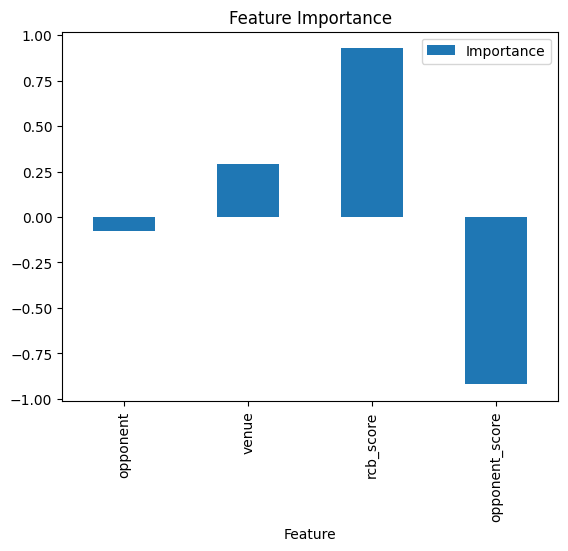

In [21]:
#Visualization

importance.plot(x="Feature",y="Importance",kind="bar")

plt.title("Feature Importance")
plt.show()

In [22]:
import joblib

joblib.dump(model,"../models/rcb_match_prediction_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [23]:
loaded_model = joblib.load("../models/rcb_match_prediction_model.pkl")

print("Model Loaded Successfully")

Model Loaded Successfully
